## 11 — Results

Collects all data tables and figures from the pipeline for the paper.

| Fig | Title | Source |
|-----|-------|--------|
| 1 | Stage 1 reductor × panel heatmap | 08 stage1_results.csv |
| 2 | Accuracy vs panel size (N=5–100) | 08 stage2_best.csv |
| 3 | Published panel comparison bar chart | 09 published_panel_results.csv + 08 stage2_best.csv |
| 4 | Confusion matrices — our N=35/50/70 | 08 our_panels_oofpreds.pkl |
| 5 | Confusion matrices — Cai / Cao / Shi-142 | 09 panel_oofpreds.pkl |
| 6 | Classifier robustness across panels | 09 published_panel_results.csv + 08 stage2_results.csv |
| 7 | SNP overlap heatmap | data/published_panels/ |

**Prerequisites**: run notebooks 08 and 09 first.

In [ ]:
import sys, pickle, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_root / 'scripts'))
from notebook_init import setup
_cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

DIR08      = PATHS.outputs_dir('self_evaluation/08_unified_panel_sweep')
DIR09      = PATHS.outputs_dir('self_evaluation/09_published_panel_comparison')
PANELS_DIR = _root / 'data' / 'published_panels'
FIG_DIR    = PATHS.outputs_dir('self_evaluation/11_results')
FIG_DIR.mkdir(parents=True, exist_ok=True)

POP_LABELS = {'CN': 'Han', 'JPT': 'JPT', 'SEA': 'SEA'}

PLT_STYLE = {'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False}
plt.rcParams.update(PLT_STYLE)
print('Output dir:', FIG_DIR)

In [ ]:
# Load all data
s2_best    = pd.read_csv(DIR08 / 'stage2_best.csv')
s2_results = pd.read_csv(DIR08 / 'stage2_results.csv')
s1_results = pd.read_csv(DIR08 / 'stage1_results.csv')
s3_results = pd.read_csv(DIR08 / 'stage3_results.csv')
pub_res    = pd.read_csv(DIR09 / 'published_panel_results.csv')

with open(DIR09 / 'panel_oofpreds.pkl', 'rb') as f:
    oof_data = pickle.load(f)
oofpreds = oof_data['oofpreds']
classes  = oof_data['classes']
classes_display = [POP_LABELS.get(c, c) for c in classes]

with open(DIR08 / 'our_panels_oofpreds.pkl', 'rb') as f:
    our_oof_data = pickle.load(f)
our_oofpreds = our_oof_data['oofpreds']

print('stage1_results:', s1_results.shape)
print('stage2_best:   ', s2_best.shape)
print('pub_results:   ', pub_res.shape)
print('OOF panels (published):', list(oofpreds.keys()))
print('OOF panels (ours):     ', list(our_oofpreds.keys()))
print('Display classes:       ', classes_display)

---
## Figure 1 — Stage 1 Reductor × Panel Heatmap

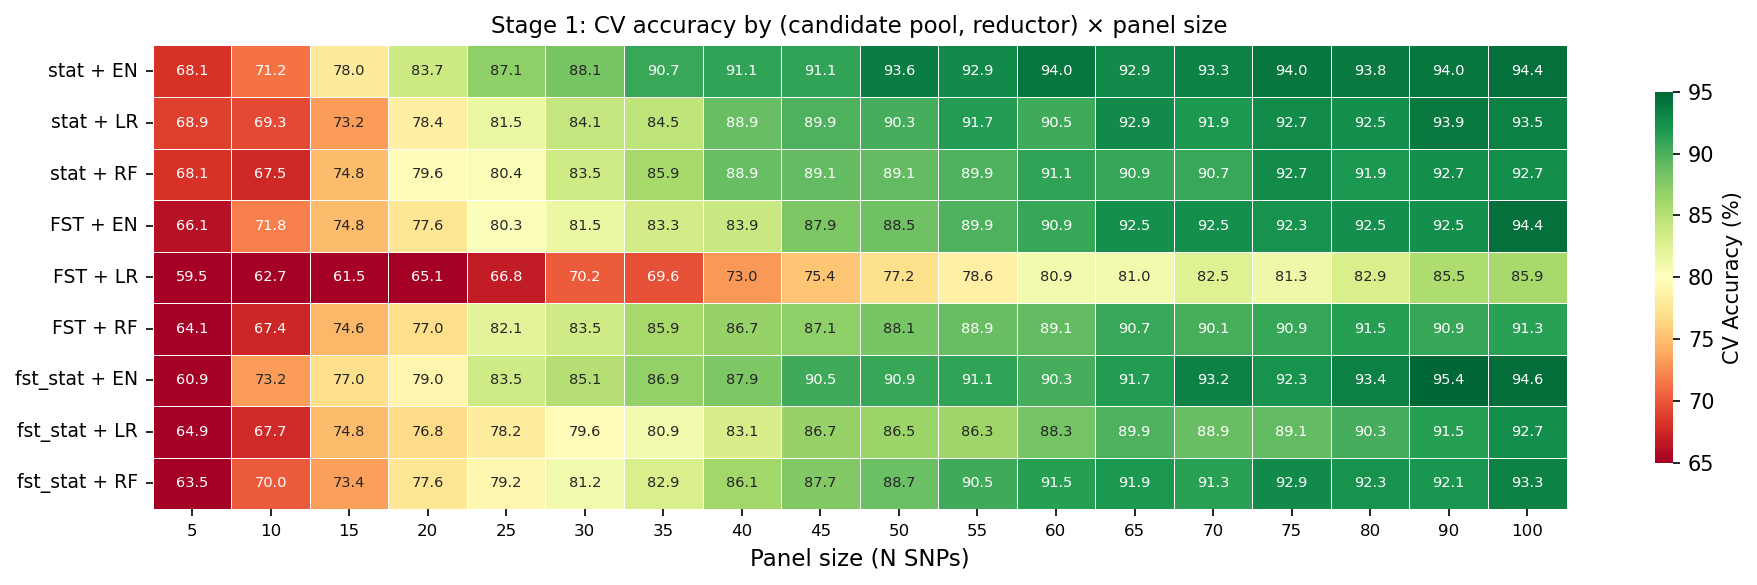

Saved fig1_stage1_heatmap.png


In [39]:
s1 = s1_results.copy()
s1['config'] = s1['panel'] + ' + ' + s1['reductor']
pivot = s1.pivot_table(index='config', columns='n_snps', values='acc_mean')

row_order = [r for r in [
    'stat + EN', 'stat + LR', 'stat + RF',
    'FST + EN',  'FST + LR',  'FST + RF',
    'fst_stat + EN', 'fst_stat + LR', 'fst_stat + RF'
] if r in pivot.index]
pivot = pivot.loc[row_order]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot * 100, ax=ax, cmap='RdYlGn', vmin=65, vmax=95,
            annot=True, fmt='.1f', annot_kws={'size': 7},
            linewidths=0.3,
            cbar_kws={'label': 'CV Accuracy (%)', 'shrink': 0.8})

ax.set_xlabel('Panel size (N SNPs)', fontsize=11)
ax.set_ylabel('')
ax.set_title('Stage 1: CV accuracy by (candidate pool, reductor) × panel size', fontsize=11)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_stage1_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig1_stage1_heatmap.png')

---
## Figure 2 — Accuracy vs Panel Size

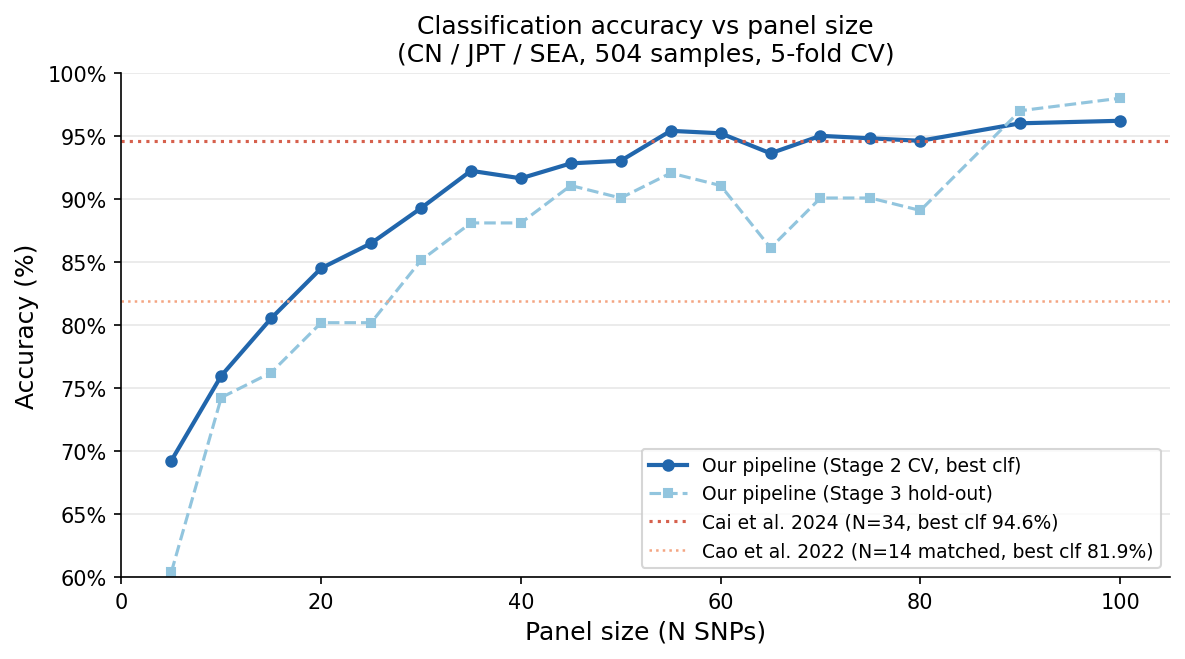

Saved fig2_accuracy_vs_n.png


In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(s2_best['n_snps'], s2_best['acc_mean'] * 100,
        'o-', color='#2166ac', linewidth=2, markersize=5,
        label='Our pipeline (Stage 2 CV, best clf)')
ax.plot(s3_results['n_snps'], s3_results['acc'] * 100,
        's--', color='#92c5de', linewidth=1.5, markersize=4,
        label='Our pipeline (Stage 3 hold-out)')

cai_best = pub_res[pub_res['panel'] == 'cai_eas34']['acc'].max() * 100
cao_best = pub_res[pub_res['panel'] == 'cao_19']['acc'].max()   * 100
ax.axhline(cai_best, color='#d6604d', linewidth=1.5, linestyle=':',
           label=f'Cai et al. 2024 (N=34, best clf {cai_best:.1f}%)')
ax.axhline(cao_best, color='#f4a582', linewidth=1.2, linestyle=':',
           label=f'Cao et al. 2022 (N=14 matched, best clf {cao_best:.1f}%)')

ax.set_xlabel('Panel size (N SNPs)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Classification accuracy vs panel size\n(CN / JPT / SEA, 504 samples, 5-fold CV)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_xlim(0, 105)
ax.set_ylim(60, 100)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_accuracy_vs_n.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig2_accuracy_vs_n.png')

---
## Figure 3 — Published Panel Comparison

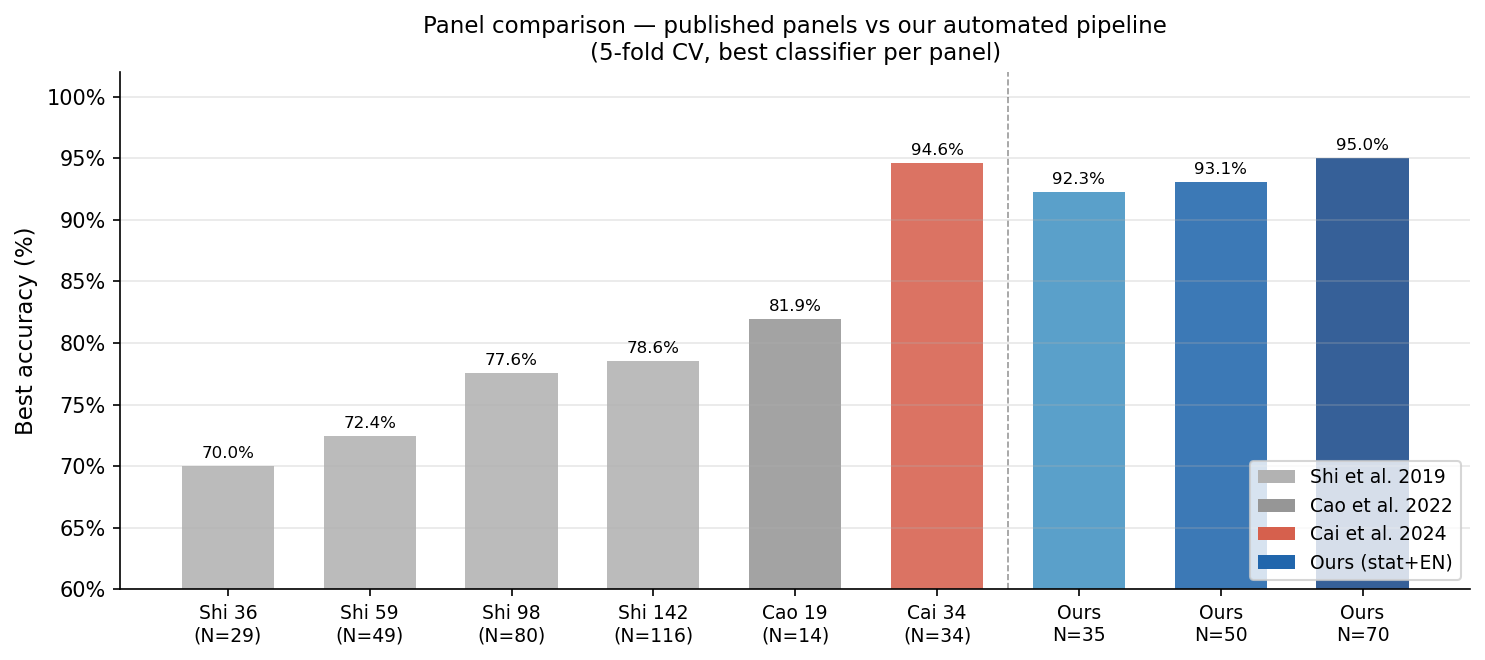

Saved fig3_panel_comparison.png


In [41]:
pub_best = pub_res.groupby('panel')['acc'].max().reset_index()
pub_best['n_snps'] = pub_res.groupby('panel')['n_snps'].first().values

our_pts = s2_best[s2_best['n_snps'].isin([35, 50, 70])][['n_snps','acc_mean']].copy()
our_pts.columns = ['n_snps', 'acc']
our_pts['panel'] = our_pts['n_snps'].apply(lambda n: f'Ours N={n}')

panel_order = ['shi_36','shi_59','shi_98','shi_142','cao_19','cai_eas34',
               'Ours N=35','Ours N=50','Ours N=70']
all_pts = pd.concat([pub_best, our_pts], ignore_index=True)
all_pts = all_pts.set_index('panel').reindex(panel_order).reset_index()

labels = [
    f"Shi 36\n(N={int(all_pts.loc[0,'n_snps'])})",
    f"Shi 59\n(N={int(all_pts.loc[1,'n_snps'])})",
    f"Shi 98\n(N={int(all_pts.loc[2,'n_snps'])})",
    f"Shi 142\n(N={int(all_pts.loc[3,'n_snps'])})",
    f"Cao 19\n(N={int(all_pts.loc[4,'n_snps'])})",
    "Cai 34\n(N=34)",
    "Ours\nN=35", "Ours\nN=50", "Ours\nN=70"
]
bar_colors = ['#b2b2b2']*4 + ['#969696'] + ['#d6604d'] + ['#4393c3','#2166ac','#1a4a8a']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(range(len(all_pts)), all_pts['acc'] * 100,
              color=bar_colors, alpha=0.88, width=0.65)

for bar, val in zip(bars, all_pts['acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(all_pts)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Best accuracy (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_ylim(60, 102)
ax.set_title('Panel comparison — published panels vs our automated pipeline\n(5-fold CV, best classifier per panel)', fontsize=11)
ax.axvline(5.5, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#b2b2b2', label='Shi et al. 2019'),
    Patch(facecolor='#969696', label='Cao et al. 2022'),
    Patch(facecolor='#d6604d', label='Cai et al. 2024'),
    Patch(facecolor='#2166ac', label='Ours (stat+EN)'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_panel_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig3_panel_comparison.png')

---
## Figure 4 — Confusion Matrices: Our Committed Panels

In [ ]:
def draw_cm(ax, y_true, y_pred, title):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, ax=ax, annot=False, cmap='Blues',
                xticklabels=classes_display, yticklabels=classes_display,
                vmin=0, vmax=100, cbar=False)
    for i in range(3):
        for j in range(3):
            color = 'white' if cm_pct[i, j] > 60 else 'black'
            ax.text(j+0.5, i+0.42, str(cm[i,j]),
                    ha='center', va='center', fontsize=13, fontweight='bold', color=color)
            ax.text(j+0.5, i+0.68, f'{cm_pct[i,j]:.1f}%',
                    ha='center', va='center', fontsize=8, color=color, alpha=0.85)
    acc = np.diag(cm).sum() / cm.sum() * 100
    ax.set_title(f'{title}\nacc={acc:.1f}%', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

our_panels = [
    ('N=35', s2_best[s2_best['n_snps']==35]['classifier'].iloc[0], 'Ours N=35 (stat+EN)'),
    ('N=50', s2_best[s2_best['n_snps']==50]['classifier'].iloc[0], 'Ours N=50 (stat+EN)'),
    ('N=70', s2_best[s2_best['n_snps']==70]['classifier'].iloc[0], 'Ours N=70 (stat+EN)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (key, clf, title) in zip(axes, our_panels):
    y_true, y_pred = our_oofpreds[key]
    draw_cm(ax, y_true, y_pred, f'{title}\n{clf}')

plt.suptitle('Figure 4 — Our committed panels (5-fold OOF)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_confusion_ours.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig4_confusion_ours.png')

---
## Figure 5 — Confusion Matrices: Published Panels

In [ ]:
def best_clf_for(panel_name):
    rows = pub_res[pub_res['panel'] == panel_name]
    return rows.loc[rows['acc'].idxmax(), 'classifier'] if not rows.empty else None

pub_panels = [
    ('cai_eas34', best_clf_for('cai_eas34'), 'Cai et al. 2024 (N=34)'),
    ('cao_19',    best_clf_for('cao_19'),    'Cao et al. 2022 (N=14 matched)'),
    ('shi_142',   best_clf_for('shi_142'),   'Shi et al. 2019 (N=116 matched)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (pname, clf, title) in zip(axes, pub_panels):
    y_true, y_pred = oofpreds[pname][clf]
    draw_cm(ax, y_true, y_pred, f'{title}\n{clf}')

plt.suptitle('Figure 5 — Published panels (5-fold OOF)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_confusion_published.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig5_confusion_published.png')

---
## Figure 6 — Classifier Robustness

In [ ]:
our35 = s2_results[s2_results['n_snps'] == 35].groupby('classifier')['acc'].mean().reset_index()
our35['panel_label'] = 'Ours N=35'
our50 = s2_results[s2_results['n_snps'] == 50].groupby('classifier')['acc'].mean().reset_index()
our50['panel_label'] = 'Ours N=50'
cai_df = pub_res[pub_res['panel'] == 'cai_eas34'][['classifier','acc']].copy()
cai_df['panel_label'] = 'Cai N=34'

combined    = pd.concat([our35, our50, cai_df], ignore_index=True)
clf_order   = ['RF', 'XGB', 'LR', 'SVM_RBF', 'SVM_Lin', 'GBM']
panel_order = ['Cai N=34', 'Ours N=35', 'Ours N=50']
colors      = {'Cai N=34': '#d6604d', 'Ours N=35': '#4393c3', 'Ours N=50': '#2166ac'}

fig, ax = plt.subplots(figsize=(9, 4.5))
x     = np.arange(len(clf_order))
width = 0.25

for i, plabel in enumerate(panel_order):
    sub  = combined[combined['panel_label'] == plabel].set_index('classifier')
    vals = [sub.loc[c, 'acc'] * 100 if c in sub.index else np.nan for c in clf_order]
    ax.bar(x + (i - 1) * width, vals, width,
           label=plabel, color=colors[plabel], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(clf_order, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_ylim(80, 100)
ax.set_title('Classifier robustness: Cai expert panel vs our automated panels', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_classifier_robustness.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig6_classifier_robustness.png')

---
## Figure 7 — SNP Overlap Heatmap

In [ ]:
def load_txt(fname):
    return set(l.strip() for l in open(PANELS_DIR / fname) if l.strip())

cai_coords_list = []
with open(PANELS_DIR / 'cai_eas34_coords.tsv') as f:
    for line in f:
        cai_coords_list.append(line.strip().split('\t')[2])

rsid_map = {}
with open(PANELS_DIR / 'our_panels_rsid_map.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rsid_map[row['snp_id']] = row['rsid']

OUR_PANELS_DIR = PATHS.outputs_dir('self_evaluation/08_unified_panel_sweep') / 'panels'

def load_our_panel(n):
    p = OUR_PANELS_DIR / f'panel_N{n:03d}.csv'
    if not p.exists(): return set()
    rsids = set()
    with open(p) as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            rsid = rsid_map.get(row[1])
            if rsid: rsids.add(rsid)
    return rsids

panel_sets = {
    'Shi 36':    load_txt('shi_36.txt'),
    'Shi 59':    load_txt('shi_59.txt'),
    'Shi 98':    load_txt('shi_98.txt'),
    'Shi 142':   load_txt('shi_142.txt'),
    'Cao 19':    load_txt('cao_19.txt'),
    'Cai 34':    set(cai_coords_list),
    'Ours N=35': load_our_panel(35),
    'Ours N=50': load_our_panel(50),
    'Ours N=70': load_our_panel(70),
}

for k, v in panel_sets.items():
    print(f'  {k:<12}: {len(v)} SNPs')

keys    = list(panel_sets.keys())
n       = len(keys)
mat_jac = np.zeros((n, n))
mat_abs = np.zeros((n, n), dtype=int)
for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        inter         = len(panel_sets[k1] & panel_sets[k2])
        union         = len(panel_sets[k1] | panel_sets[k2])
        mat_jac[i, j] = inter / union if union > 0 else 0
        mat_abs[i, j] = inter

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(mat_abs, ax=axes[0], annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=keys, yticklabels=keys, linewidths=0.5,
            cbar_kws={'label': 'Shared SNPs (count)'})
axes[0].set_title('Absolute SNP overlap (count)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

sns.heatmap(mat_jac, ax=axes[1], annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=keys, yticklabels=keys, linewidths=0.5,
            vmin=0, vmax=1, cbar_kws={'label': 'Jaccard similarity'})
axes[1].set_title('Jaccard similarity (shared / union)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('SNP panel overlap — published panels vs our committed panels', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_overlap_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig7_overlap_heatmap.png')

---
## Key Tables

In [45]:
# Table 1 — Stage 2 accuracy for all 6 classifiers at key panel sizes (stat + ElasticNet)
key_n     = [35, 50, 70]
clf_order = ['RF', 'XGB', 'LR', 'SVM_RBF', 'SVM_Lin', 'GBM']

sub   = s2_results[s2_results['n_snps'].isin(key_n)].copy()
pivot = sub.pivot_table(index='classifier', columns='n_snps', values='acc', aggfunc='mean')
pivot = pivot.reindex(clf_order) * 100
pivot.columns = [f'N={c} Acc (%)' for c in pivot.columns]
pivot = pivot.round(2)
pivot.index.name = 'Classifier'
t1 = pivot.reset_index()

print('Table 1 — Stage 2 accuracy (stat + ElasticNet reductor, 5-fold CV, all classifiers)')
display(t1.style.highlight_max(subset=[c for c in t1.columns if 'Acc' in c],
                                axis=0, props='font-weight: bold'))
t1.to_csv(FIG_DIR / 'table1_our_pipeline.csv', index=False)

print()

# Table 2 — Published panel benchmarking (best per panel)
pub_best_full = pub_res.loc[pub_res.groupby('panel')['acc'].idxmax()].copy()
pub_order = ['shi_36','shi_59','shi_98','shi_142','cao_19','cai_eas34']
t2 = pub_best_full.set_index('panel').reindex(pub_order).reset_index()
t2 = t2[['panel','n_snps','classifier','acc','f1','mcc','roc_auc']]
t2.columns = ['Panel','Matched N','Best clf','Accuracy','F1','MCC','ROC-AUC']
t2[['Accuracy','F1','MCC','ROC-AUC']] = t2[['Accuracy','F1','MCC','ROC-AUC']].round(4)
t2 = t2.reset_index(drop=True)

print('Table 2 — Published panels (best classifier, 5-fold CV on our 504-sample cohort)')
display(t2)
t2.to_csv(FIG_DIR / 'table2_published_panels.csv', index=False)

print(f'\nCSVs saved to {FIG_DIR}')

Table 1 — Stage 2 accuracy (stat + ElasticNet reductor, 5-fold CV, all classifiers)


,Classifier,N=35 Acc (%),N=50 Acc (%),N=70 Acc (%)
0,RF,89.880000,92.850000,93.850000
1,XGB,90.470000,91.660000,93.260000
2,LR,92.260000,93.050000,94.440000
3,SVM_RBF,91.270000,93.050000,95.040000
4,SVM_Lin,89.870000,91.670000,93.850000
5,GBM,87.890000,88.480000,92.260000



Table 2 — Published panels (best classifier, 5-fold CV on our 504-sample cohort)


,Panel,Matched N,Best clf,Accuracy,F1,MCC,ROC-AUC
0,shi_36,29,LR,0.7005,0.6992,0.5359,0.8469
1,shi_59,49,SVM_RBF,0.7242,0.7223,0.5725,0.8560
2,shi_98,80,SVM_RBF,0.7758,0.7744,0.6541,0.8952
3,shi_142,116,SVM_RBF,0.7857,0.7850,0.6680,0.9087
4,cao_19,14,LR,0.8194,0.8190,0.7188,0.9428
5,cai_eas34,34,SVM_RBF,0.9464,0.9464,0.9174,0.9909



CSVs saved to /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results
